# CUSTOMER SEGMENTATION PROJECT USING RFM


In [1]:
# Business Problem
# The company wants to understand customer purchasing behavior, identify valuable customers, reduce churn,
# and improve marketing strategies using customer segmentation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_palette('deep')

In [3]:
df=pd.read_csv(r'C:\Users\Sahil Singh\Sam_Analysis/04_Project_Customer_Segmentation/ecommerce_customer_data.csv')

# Dataset Overview

In [4]:
# Display First 10 rows
df.head(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
5,13738,2022-08-25 06:48:33,Home,191,3,3722,Credit Card,27,1.0,Lauren Johnson,27,Female,0
6,13738,2023-07-25 05:17:24,Electronics,205,1,2773,Credit Card,27,NaN,Lauren Johnson,27,Female,0
7,13738,2023-02-05 19:31:48,Books,370,5,1486,Cash,27,1.0,Lauren Johnson,27,Female,0
8,13738,2021-12-21 03:29:05,Home,12,2,2175,Cash,27,NaN,Lauren Johnson,27,Female,0
9,13738,2023-02-09 00:53:14,Electronics,40,4,4327,Cash,27,0.0,Lauren Johnson,27,Female,0


In [5]:
# Display Last 10 rows
df.tail(10)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
249990,150,2023-08-23 01:47:29,Home,196,3,1743,PayPal,68,0.0,Stephanie Morris,68,Male,0
249991,16247,2020-06-24 17:29:27,Electronics,368,1,1720,Credit Card,22,0.0,Mike Thompson,22,Male,0
249992,48538,2020-12-13 02:09:15,Electronics,239,1,2356,Cash,61,1.0,Alexis Nelson,61,Male,1
249993,39806,2021-12-07 05:42:38,Electronics,215,3,2349,Cash,60,1.0,Dana Brown,60,Female,0
249994,39806,2021-08-01 04:43:12,Electronics,225,5,5293,Credit Card,60,0.0,Dana Brown,60,Female,0
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0
249999,4148,2020-09-07 05:12:19,Home,307,5,3634,Cash,32,0.0,Angela Norton,32,Male,0


In [6]:
# Displays Columns Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.0 MB


In [7]:
# Display Statistical Summmary
df.describe(include='all')

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
count,250000.000000,250000,250000,250000.000000,250000.000000,250000.000000,250000,250000.000000,202618.000000,250000,250000.000000,250000,250000.00000
unique,NaN,249728,4,NaN,NaN,NaN,3,NaN,NaN,39878,NaN,2,NaN
top,NaN,2021-12-25 13:07:57,Electronics,NaN,NaN,NaN,Credit Card,NaN,NaN,Michael Johnson,NaN,Male,NaN
freq,NaN,2,62630,NaN,NaN,NaN,83547,NaN,NaN,119,NaN,125676,NaN
mean,25017.632092,NaN,NaN,254.742724,3.004936,2725.385196,NaN,43.798276,0.500824,NaN,43.798276,NaN,0.20052
std,14412.515718,NaN,NaN,141.738104,1.414737,1442.576095,NaN,15.364915,0.500001,NaN,15.364915,NaN,0.40039
min,1.000000,NaN,NaN,10.000000,1.000000,100.000000,NaN,18.000000,0.000000,NaN,18.000000,NaN,0.00000
25%,12590.000000,NaN,NaN,132.000000,2.000000,1476.000000,NaN,30.000000,0.000000,NaN,30.000000,NaN,0.00000
50%,25011.000000,NaN,NaN,255.000000,3.000000,2725.000000,NaN,44.000000,1.000000,NaN,44.000000,NaN,0.00000
75%,37441.250000,NaN,NaN,377.000000,4.000000,3975.000000,NaN,57.000000,1.000000,NaN,57.000000,NaN,0.00000


In [8]:
# Checking Columns name
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

# Data Cleaning

In [9]:
# Checking Missinng values
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [10]:
# Handling missing values
df['Returns']=df['Returns'].fillna(0)  # Missing return values assumed as no returns

In [11]:
# Checking Duplicates
df.duplicated().sum()  # No duplicates present.

np.int64(0)

In [12]:
# Dropping Columns
df.drop('Customer Age',axis=1,inplace=True)  #Dropping Column 'Customer Age' because it is double.

In [13]:
#Standardize the data 
df=df.rename(columns={'Purchase Date':'Date','Product Category':'Category','Product Price':'Price','Total Purchase Amount':'Revenue'})
df.columns=df.columns.str.lower().str.strip().str.replace(' ','_')
df.columns

Index(['customer_id', 'date', 'category', 'price', 'quantity', 'revenue',
       'payment_method', 'returns', 'customer_name', 'age', 'gender', 'churn'],
      dtype='str')

In [14]:
# Fixing Data type of column 'date'
df['date']=pd.to_datetime(df['date'],format='mixed')  #Column 'date' datatype was 'str', now change into datetime
df['date'].dtype

dtype('<M8[us]')

In [15]:
# Feature Engineering

In [16]:
df['month']=df['date'].dt.month_name()

In [17]:
# Creating a customer age segment for demographic analysis
label=['Young adult','Adult','Middle age','Senior']
bins=[0,24,34,64,100]
df['age_group']=pd.cut(df['age'],bins=bins,labels=label)
df[['age','age_group']].head(10)

,age,age_group
0,31,Adult
1,31,Adult
2,31,Adult
3,31,Adult
4,31,Adult
5,27,Adult
6,27,Adult
7,27,Adult
8,27,Adult
9,27,Adult


In [18]:
#Checking Distribution
df['age_group'].value_counts()

age_group
Middle age     139904
Adult           47679
Young adult     34182
Senior          28235
Name: count, dtype: int64

In [19]:
# Checking OutLiers

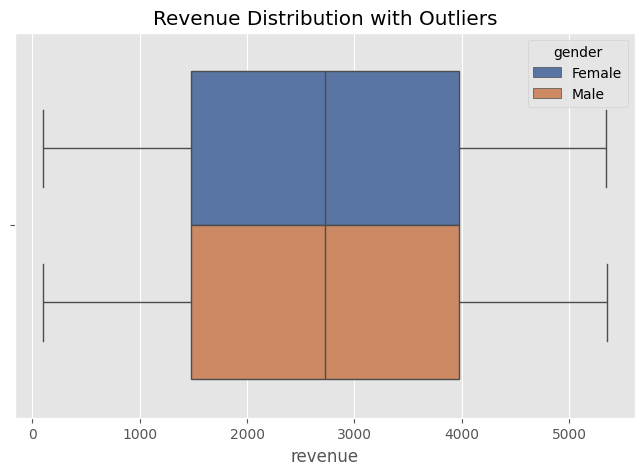

In [55]:
# Outlier In Renvenue
plt.figure(figsize=(8,5))
sns.boxplot(x='revenue',data=df,hue='gender')  

plt.title('Revenue Distribution with Outliers')
plt.show()

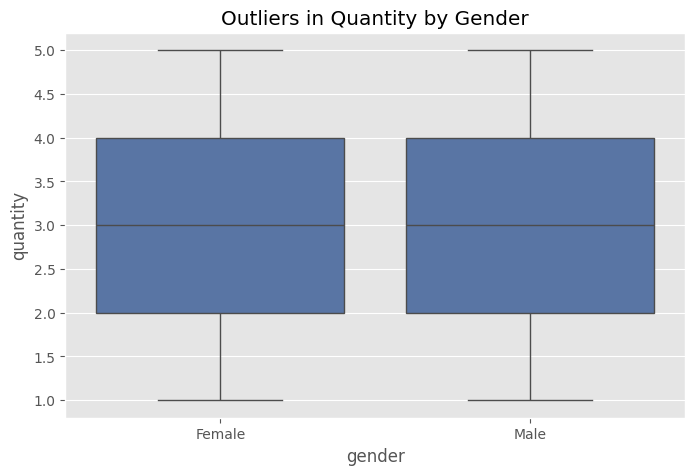

In [57]:
# Outliers In Quatity
plt.figure(figsize=(8,5))
sns.boxplot(x='gender',y='quantity',data=df)  

plt.title('Outliers in Quantity by Gender')
plt.show()

# Exploratory Data Analysis

In [22]:
# Sales Analysis

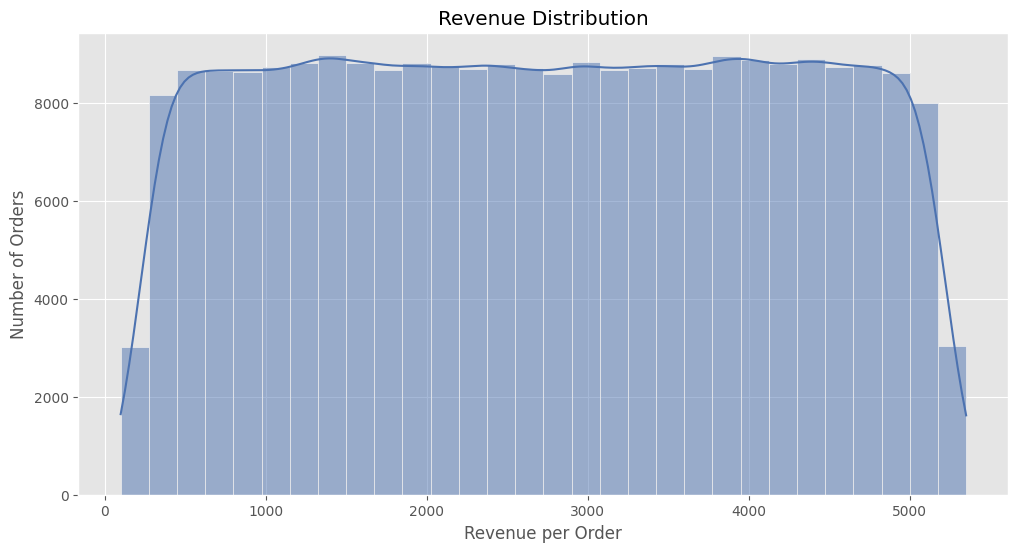

In [23]:
# Revenue Distribution
plt.figure(figsize=(12,6))
sns.histplot(x='revenue', data=df, bins=30, kde=True)

plt.title('Revenue Distribution')
plt.xlabel('Revenue per Order')
plt.ylabel('Number of Orders')
plt.show()

In [24]:
# Revenue distribution is relatively uniform across order values, indicating that customers purchase products across
# multiple pricing ranges rather than concentrating on low-cost items only.

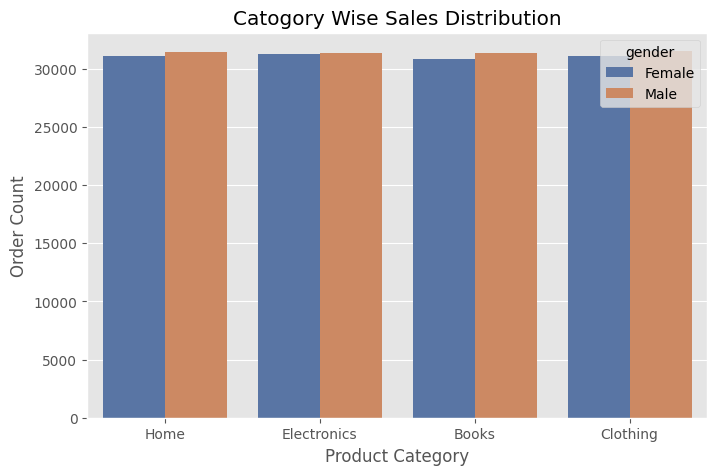

In [25]:
# Top Category
plt.figure(figsize=(8,5))
sns.countplot(x='category',data=df,hue='gender')

plt.title('Catogory Wise Sales Distribution')
plt.xlabel('Product Category')
plt.ylabel('Order Count')
plt.show()

In [26]:
# Insight:-
# Sales distribution across product categories is highly balanced, with Electronics contributing the highest share at 25.05% of total orders,
# closely followed by Clothing and Home categories.

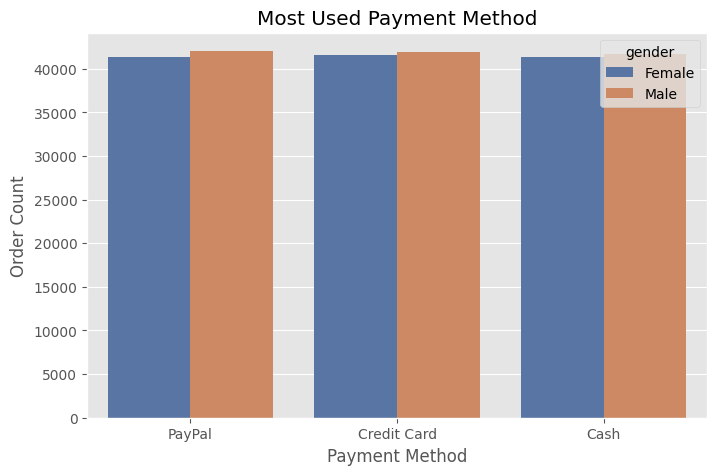

In [27]:
# Question which Payment Method is most Used?

plt.figure(figsize=(8,5))
sns.countplot(x='payment_method',data=df,hue='gender')

plt.title('Most Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Order Count')
plt.show()

In [28]:
# Insight:-
# Customer payment preferences are highly distributed across Credit Card (33.42%), PayPal (33.38%), and Cash (33.20%)
# indicating balanced adoption of multiple payment methods.

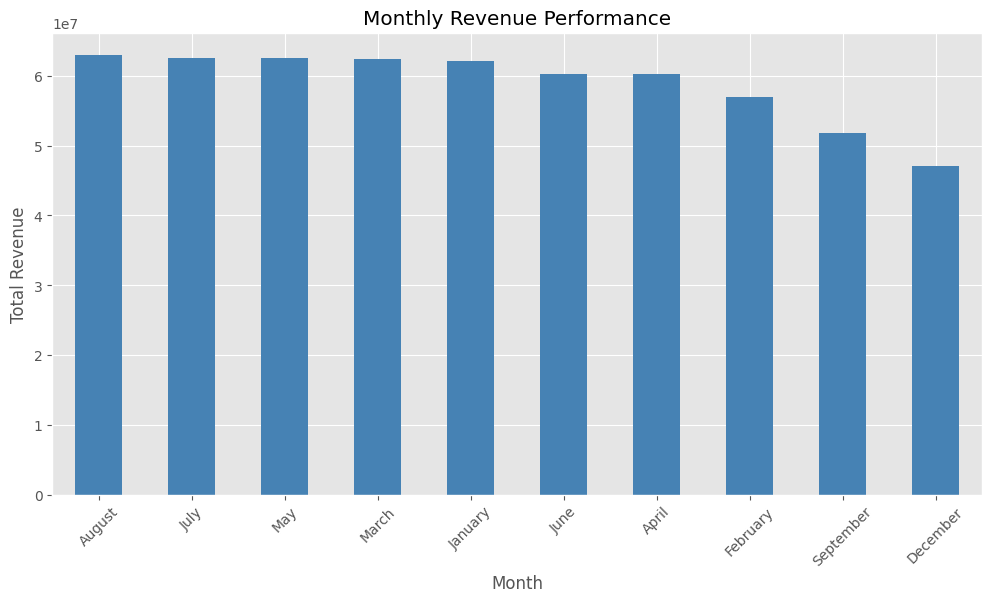

In [29]:
# Question- Which month genrate the highest revenue?

Top_month=df.groupby('month')['revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

Top_month.plot(kind='bar',color='steelblue')

plt.title('Monthly Revenue Performance')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [30]:
# Insight:-
# Monthly revenue performance indicates fluctuations in customer purchasing behavior, 
# suggesting possible seasonal demand trends and changing customer activity patterns.

In [31]:
# Customer Analysis

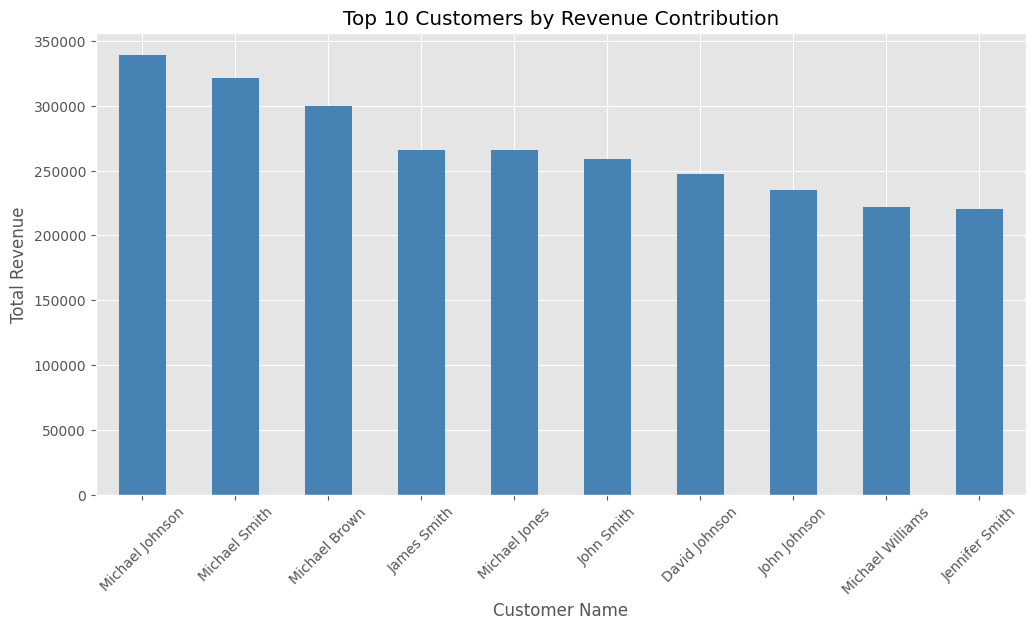

In [32]:
# Question- Who spend the most ?

Top_Customer=df.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

Top_Customer.plot(kind='bar',color='steelblue')

plt.title('Top 10 Customers by Revenue Contribution')
plt.xlabel('Customer Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Insight:-
# A small number of high-value customers contribute significantly to overall revenue, 
# with Michael Johnson alone generating over ₹339K in purchases.

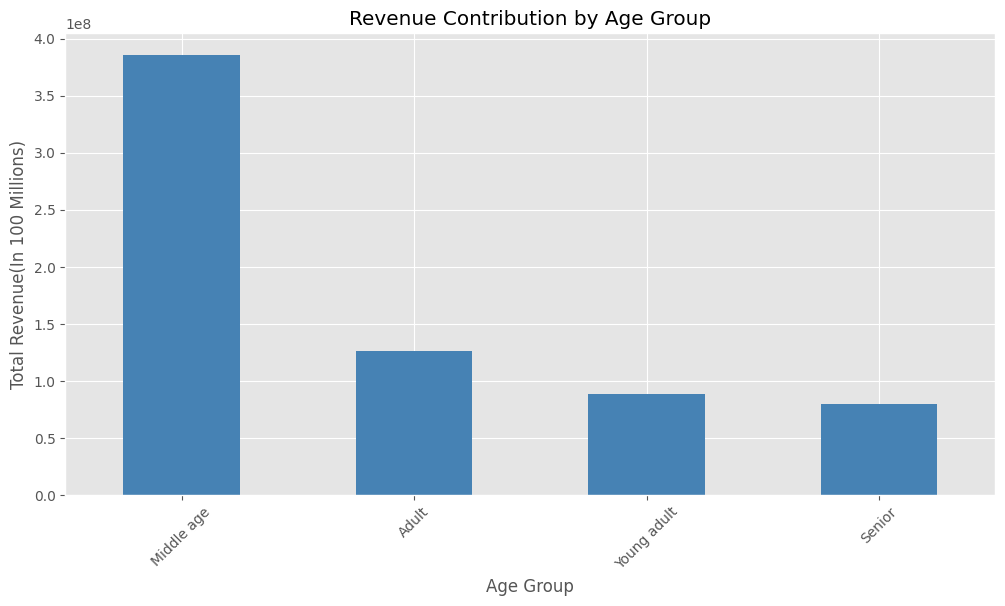

In [34]:
# Question- Which Age Group spend most?

Top_AgeGroup=df.groupby('age_group')['revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

Top_AgeGroup.plot(kind='bar',color='steelblue')

plt.title('Revenue Contribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue(In 100 Millions)')
plt.xticks(rotation=45)
plt.show()

In [35]:
# Insight:-
# Customers aged 56–65 contribute the highest share of total revenue at 19.59%, 
# indicating stronger purchasing power among older customer groups.

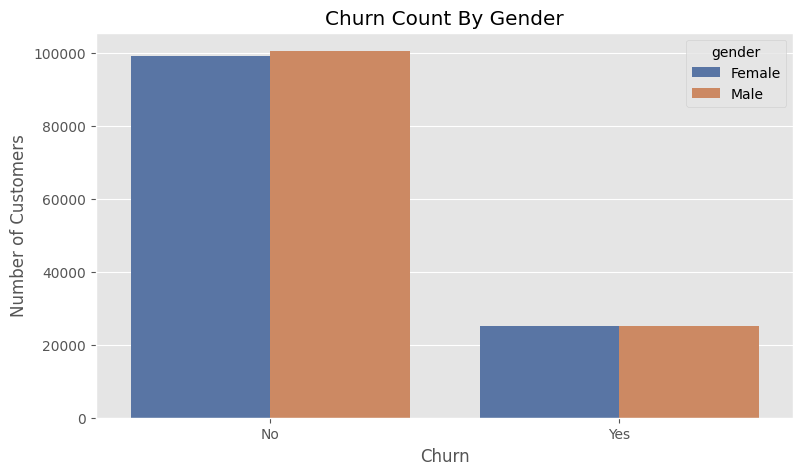

In [36]:
# Which gender has higher churn among customers

df['churn_label']=df['churn'].replace({0:'No',1:'Yes'})

plt.figure(figsize=(9,5))
sns.countplot(x='churn_label', data=df,hue='gender')
plt.title('Churn Count By Gender')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [37]:
# Insight:-
# Female customers exhibit a slightly higher churn rate (20.16%) compared to male customers (19.94%),
# although churn behavior remains relatively similar across both genders.

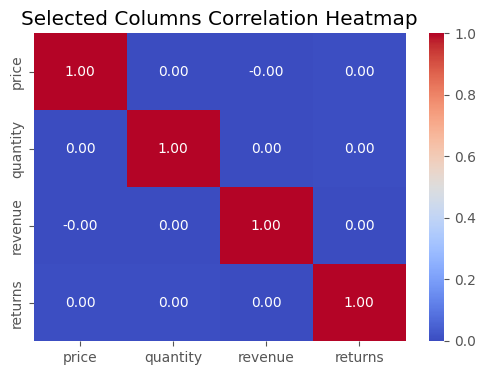

In [65]:
# Heat map for finding correlation

selected_cols = ['price', 'quantity', 'revenue', 'returns']
correlation = df[selected_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Selected Columns Correlation Heatmap')
plt.show()

In [ ]:
# Insight:-
# The heatmap shows that there is very weak correlation between most variables since the values are close to 0.

# Customer Metrics (RFM)

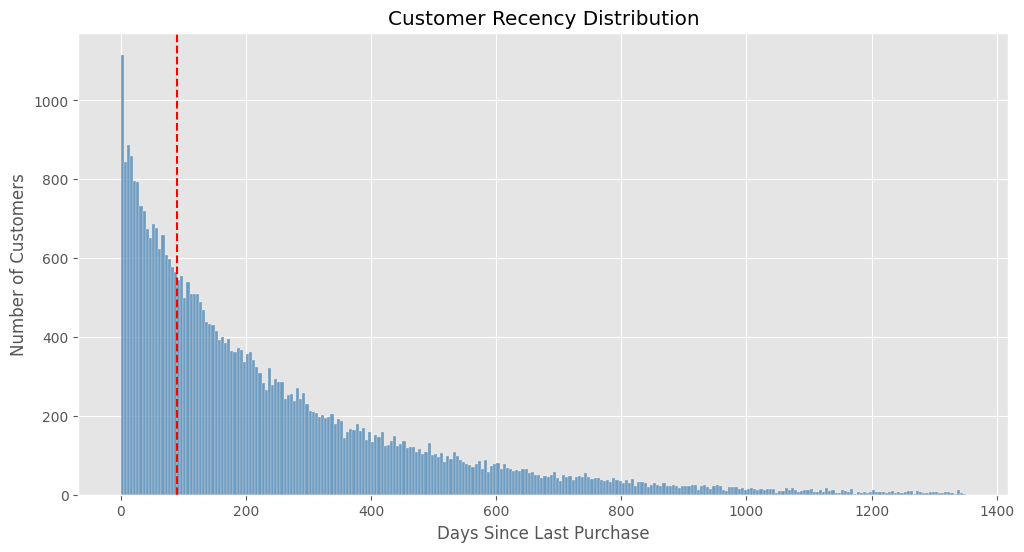

In [38]:
# Recency (How recently they bought)

Recency=df.groupby('customer_name')['date'].max()
Recency_score=(df['date'].max()-Recency).dt.days

plt.figure(figsize=(12,6))
sns.histplot(Recency_score, binwidth=5, color='steelblue') #number of customers in each recency bin (5-day intervals)

plt.axvline(90, color='red', linestyle='--', label='Churn Threshold (90 days)')
#The red dashed line at 90 days marks the churn threshold
#Customers with recency > 90 days are considered potentially churned

plt.title('Customer Recency Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')
plt.show()

In [39]:
# Insight:-
# Customer recency analysis indicates variation in purchasing activity,
# with a portion of customers showing long inactivity periods that may indicate churn risk.

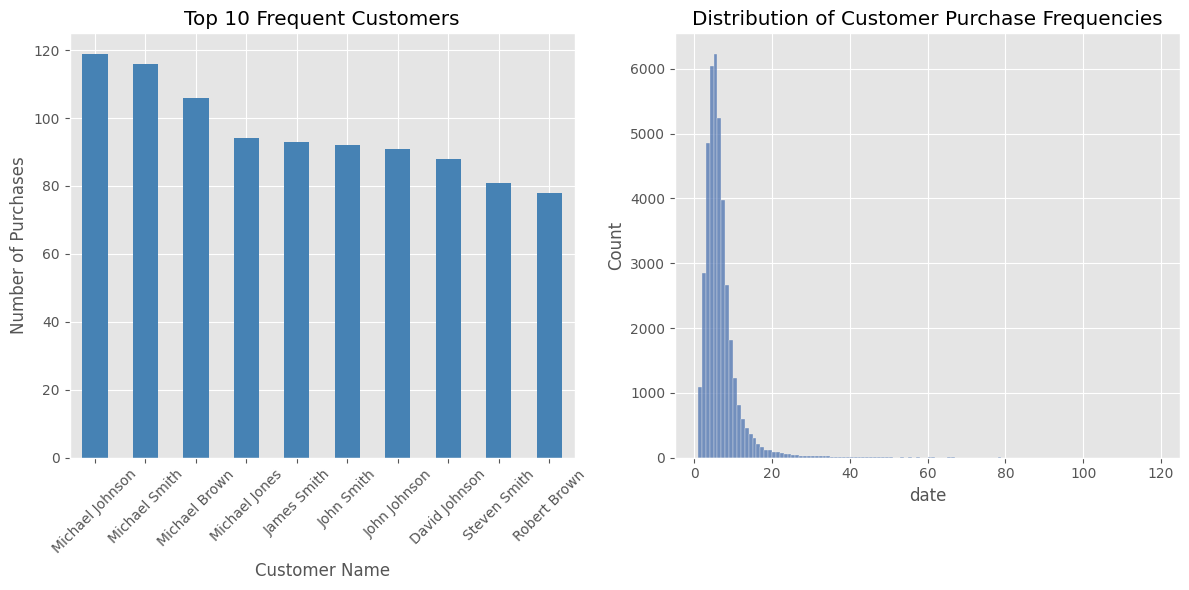

In [40]:
# Frequency (How Often They Spend)
# Dataset has multiple items per order, but no order_id, using date-based grouping

Frequent_Customers=df.groupby('customer_name')['date'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

#------------Bar-Plot-----------
plt.subplot(1,2,1)
Frequent_Customers.plot(kind='bar',color='steelblue')
plt.title('Top 10 Frequent Customers')
plt.xlabel('Customer Name')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)

#-----------Hist-Plot-----------
plt.subplot(1,2,2)
sns.histplot(df.groupby('customer_name')['date'].nunique(), binwidth=1)
plt.title('Distribution of Customer Purchase Frequencies')

plt.tight_layout()
plt.show()

In [41]:
# Insight:-
# Top customers demonstrate exceptionally high purchase frequency, with Michael Johnson making 119 purchases,
# indicating strong customer loyalty and engagement.

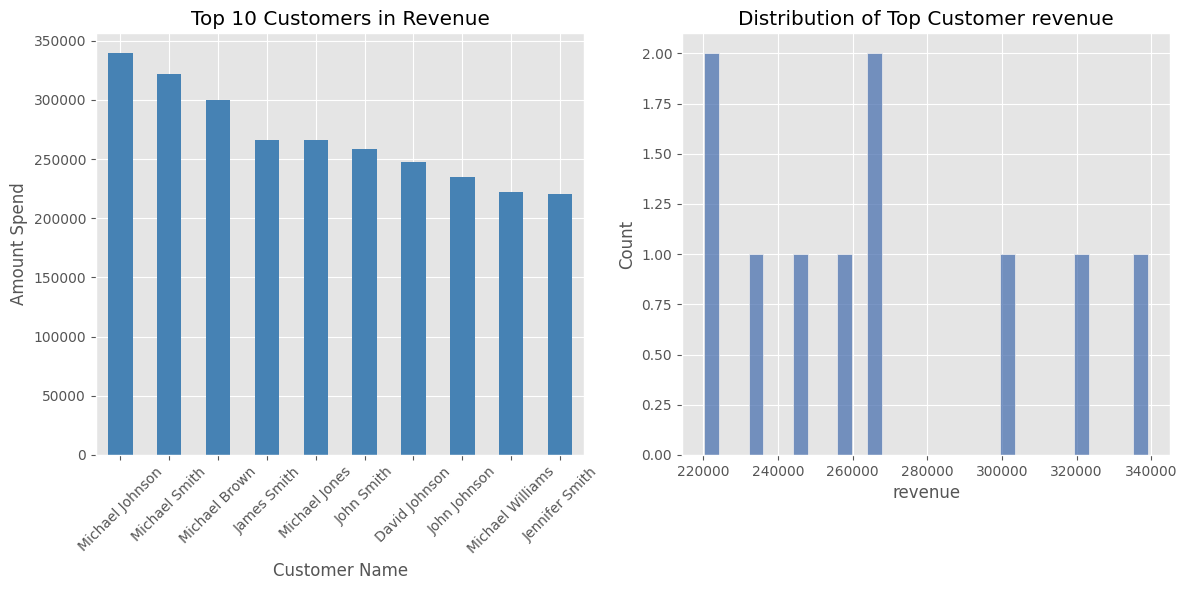

In [42]:
# Monetory(How much they spend?)

Top_Customers=df.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

#------------Bar-Plot-----------
plt.subplot(1,2,1)
Top_Customers.plot(kind='bar',color='steelblue')
plt.title('Top 10 Customers in Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Amount Spend')
plt.xticks(rotation=45)

#-----------Hist-Plot-----------
plt.subplot(1,2,2)
sns.histplot(Top_Customers, bins=30)
plt.title('Distribution of Top Customer revenue')

plt.tight_layout()
plt.show()

In [ ]:
# Insight:-
# The top customers contribute a significant portion of total revenue, with Michael Johnson being the highest spender.
# Most customers fall within the 220K–270K revenue range, while a few exceed 300K, indicating high-value VIP customers.
# The distribution is slightly right-skewed, showing that revenue is concentrated among a small group of customers.

In [43]:
# Additional Useful Customer KPIs

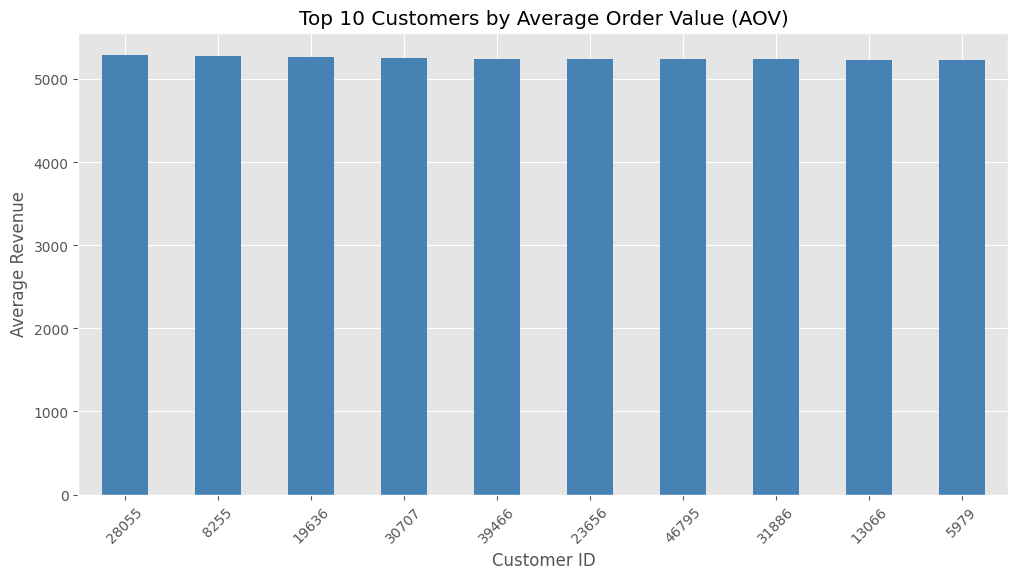

In [44]:
# Average Order Value (AOV)

AOV=df.groupby('customer_id')['revenue'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))

AOV.plot(kind='bar',color='steelblue')
plt.title('Top 10 Customers by Average Order Value (AOV)')
plt.xlabel('Customer ID')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45) 
plt.show()

In [ ]:
# Insight:-
# A small group of customers contributes disproportionately high order values, indicating the presence of premium or high-value customers.

In [45]:
#Repeat Customer Rate

Repeat_rate = (df['customer_id'].value_counts() > 1).mean()
print(f"{Repeat_rate*100:2f}%")

96.671432%


In [46]:
# Churn Indicator

Recency=df.groupby('customer_name')['date'].max()
Recency_score=(df['date'].max()-Recency).dt.days

churned = (Recency_score > 90).sum()  #Sum of Total Churn
print("Total Number of Churn",churned)
churn_rate = (Recency_score > 90).mean() * 100 #Precentage of Churn
print(f"Churn Rate: {churn_rate:.2f}%")

Total Number of Churn 26807
Churn Rate: 67.22%


# Customer Segmentation 

In [47]:
# RFM metrics

rfm = df.groupby('customer_id').agg({
    'date': lambda x: (df['date'].max() - x.max()).days,
    'revenue': 'sum',
    'customer_id': 'size'  # frequency
}).rename(columns={'date': 'Recency', 'revenue': 'Monetary', 'customer_id': 'Frequency'})

In [48]:
#Assigning Scores(1-5)

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1],duplicates='drop')  # inverted for recency
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5],duplicates='drop')
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5],duplicates='drop')

In [49]:
#Datatype conversion

rfm['R_score'] = rfm['R_score'].astype(int)  # Higher score = more recent
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [50]:
#Combine R, F, M scores into a single string

rfm['RFM_Score'] = rfm['R_score'].map(str) + rfm['F_score'].map(str) + rfm['M_score'].map(str)

In [51]:
#Creating customers segment based on RFM scores

def segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'VIP'
    elif row['F_score'] >= 4:
        return 'Loyal'
    elif row['R_score'] >= 4:
        return 'Potential'
    elif row['R_score'] <= 2:
        return 'Churn Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

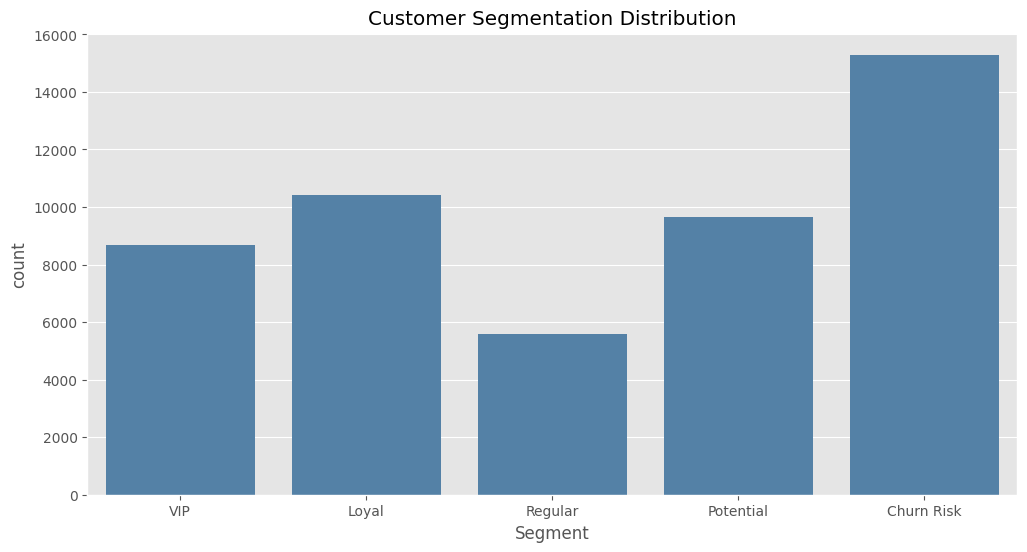

In [52]:
#The distribution of your RFM segments

plt.figure(figsize=(12,6))
sns.countplot(x='Segment', data=rfm,color='steelblue',order=['VIP','Loyal','Regular','Potential','Churn Risk'])
plt.title('Customer Segmentation Distribution')
plt.show()

In [53]:
# Insight:-
# The dataset reveals multiple customer segments including loyal customers, regular buyers, and churn-risk customers,
# highlighting diverse purchasing behaviors across the customer base.

# FINAL BUSINESS RECOMMENDATIONS